In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=120)


**Matrix basics: create, add, subtract, scalar multiply**

In [ ]:
A = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

B = np.array([[9,8,7],
              [6,5,4],
              [3,2,1]])

print("A:\n", A)
print("B:\n", B)

print("\nA + B:\n", A + B)
print("\nA - B:\n", A - B)
print("\n3.0 * A:\n", 3.0 * A)


A:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
B:
 [[9 8 7]
 [6 5 4]
 [3 2 1]]

A + B:
 [[10 10 10]
 [10 10 10]
 [10 10 10]]

A - B:
 [[-8 -6 -4]
 [-2  0  2]
 [ 4  6  8]]

3.0 * A:
 [[ 3.  6.  9.]
 [12. 15. 18.]
 [21. 24. 27.]]


**Identity matrix + ones (shape awareness)**

In [ ]:
I = np.eye(3)
Ones_3x2 = np.ones((3,2))

print("Identity I (3x3):\n", I)
print("\nOnes (3x2):\n", Ones_3x2)


Identity I (3x3):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Ones (3x2):
 [[1. 1.]
 [1. 1.]
 [1. 1.]]


**Matrix multiplication (dot) + manual nested loops**

In [ ]:
X = np.array([[1., 2., 3.],
              [4., 5., 6.]])
Y = np.array([[ 6., 23.],
              [-1.,  7.],
              [ 8.,  9.]])

print("X·Y using dot:\n", X.dot(Y))

def matmul_loops(M1, M2):
    n, m = M1.shape
    m2, p = M2.shape
    assert m == m2, "Inner dimensions must match"
    out = np.zeros((n, p), dtype=float)
    for i in range(n):
        for j in range(p):
            for k in range(m):
                out[i, j] += M1[i, k] * M2[k, j]
    return out

print("\nX·Y using loops:\n", matmul_loops(X, Y))


X·Y using dot:
 [[ 28.  64.]
 [ 67. 181.]]

X·Y using loops:
 [[ 28.  64.]
 [ 67. 181.]]


**Transpose and swapaxes**

In [ ]:
arr = np.arange(20).reshape(4,5)
print("arr:\n", arr)
print("\narr.T:\n", arr.T)

arr2 = np.array([[ 0,  1,  0],
                 [ 1,  2, -2],
                 [ 6,  3,  2],
                 [-1,  0, -1],
                 [ 1,  0,  1]])
print("\narr2.swapaxes(0,1):\n", arr2.swapaxes(0,1))


arr:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

arr.T:
 [[ 0  5 10 15]
 [ 1  6 11 16]
 [ 2  7 12 17]
 [ 3  8 13 18]
 [ 4  9 14 19]]

arr2.swapaxes(0,1):
 [[ 0  1  6 -1  1]
 [ 1  2  3  0  0]
 [ 0 -2  2 -1  1]]


**Determinant (2×2 and 3×3)**

In [ ]:
M2 = np.array([[40, 29],
               [40, 20]])
print("det(2x2):", np.linalg.det(M2))

M3 = np.array([[45, 15, 35],
               [32, 64,  9],
               [16, 15, 57]])
print("det(3x3):", np.linalg.det(M3))


det(2x2): -360.00000000000006
det(3x3): 113845.00000000007


**Inverse (3×3 and 4×4) + verify with identity**

In [ ]:
A3 = np.array([[ 4,  3,  2],
               [ 5, -5,  5],
               [-1,  6, -4]])
A3_inv = np.linalg.inv(A3)
print("A3_inv:\n", A3_inv)

print("\nA3 @ A3_inv (should be I):\n", A3 @ A3_inv)

A4 = np.array([[ 1,  1,  1, -3],
               [ 7, -2, -5,  4],
               [-3,  6,  7,  5],
               [-3,  2,  8, -4]])
A4_inv = np.linalg.inv(A4)
print("\nA4_inv:\n", A4_inv)


A3_inv:
 [[-0.18181818  0.43636364  0.45454545]
 [ 0.27272727 -0.25454545 -0.18181818]
 [ 0.45454545 -0.49090909 -0.63636364]]

A3 @ A3_inv (should be I):
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0. -0.  1.]]

A4_inv:
 [[ 0.12215569  0.16287425  0.00718563  0.08023952]
 [ 0.42275449 -0.10299401  0.14251497 -0.24191617]
 [-0.16287425  0.11616766 -0.00958084  0.22634731]
 [-0.20598802  0.05868263  0.04670659  0.02155689]]


**Triangular matrices (lower/upper)**

In [ ]:
T = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])
L = np.tril(T)
U = np.triu(T)
print("Lower triangular:\n", L)
print("\nUpper triangular:\n", U)


Lower triangular:
 [[1 0 0]
 [4 5 0]
 [7 8 9]]

Upper triangular:
 [[1 2 3]
 [0 5 6]
 [0 0 9]]


**Universal (trig/hypot) and statistical functions**

In [ ]:
angles_deg = np.array([0, 30, 45, 60, 90, 180])
angles_rad = np.deg2rad(angles_deg)
print("sin(deg):", np.sin(angles_rad))
print("arcsin back to deg:", np.rad2deg(np.arcsin(np.sin(angles_rad))))
print("cosh:", np.cosh(angles_rad))
print("hypot(5,2):", np.hypot(5, 2))

weights = np.array([48.2, 52.0, 56.0, 58.0, 51.3, 65.6, 47.1, 49.0])
print("\nmin/max:", np.amin(weights), np.amax(weights))
print("range (ptp):", np.ptp(weights))
print("70th percentile:", np.percentile(weights, 70))
print("mean:", np.mean(weights))
print("median:", np.median(weights))
print("std:", np.std(weights))
print("var:", np.var(weights))
print("average:", np.average(weights))


sin(deg): [0.         0.5        0.70710678 0.8660254  1.         0.        ]
arcsin back to deg: [ 0. 30. 45. 60. 90.  0.]
cosh: [ 1.          1.14023832  1.32460909  1.60028686  2.50917848 11.59195328]
hypot(5,2): 5.385164807134504

min/max: 47.1 65.6
range (ptp): 18.499999999999993
70th percentile: 55.599999999999994
mean: 53.4
median: 51.65
std: 5.801077486122726
var: 33.652499999999975
average: 53.4


**Solve linear systems (unique / no / infinite)**

Unique solution x: [-0.58226371  3.22870478 -1.98599767]


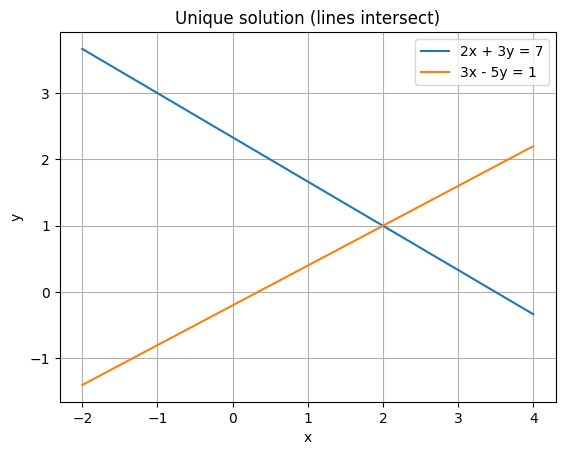

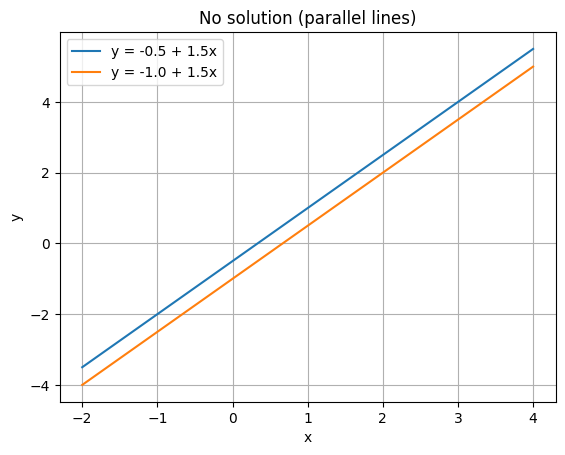

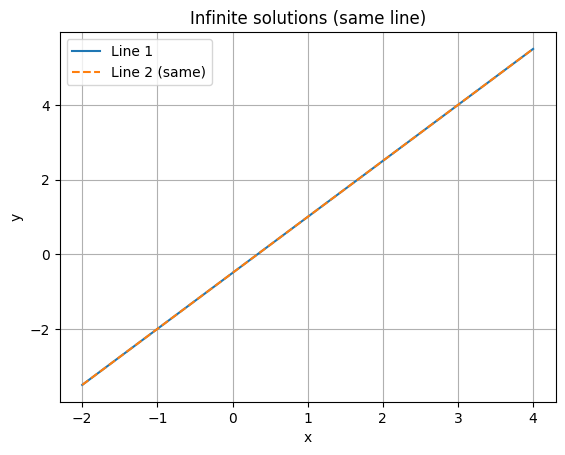

In [ ]:
# Unique solution (3x3)
A = np.array([[ 8, 3, -2],
              [-4, 7,  5],
              [ 3, 4, -12]])
b = np.array([9, 15, 35])
x = np.linalg.solve(A, b)
print("Unique solution x:", x)

t = np.linspace(-2, 4, 100)
y1 = (7 - 2*t)/3
y2 = (3*t - 1)/5
plt.figure()
plt.plot(t, y1, label="2x + 3y = 7")
plt.plot(t, y2, label="3x - 5y = 1")
plt.legend(); plt.title("Unique solution (lines intersect)")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
plt.show()

y3 = -0.5 + 1.5*t
y4 = -1.0 + 1.5*t
plt.figure()
plt.plot(t, y3, label="y = -0.5 + 1.5x")
plt.plot(t, y4, label="y = -1.0 + 1.5x")
plt.legend(); plt.title("No solution (parallel lines)")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
plt.show()

y5 = -0.5 + 1.5*t
y6 = -0.5 + 1.5*t
plt.figure()
plt.plot(t, y5, label="Line 1")
plt.plot(t, y6, linestyle="--", label="Line 2 (same)")
plt.legend(); plt.title("Infinite solutions (same line)")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
plt.show()


**Eigenvalues and eigenvectors**

In [ ]:
M = np.array([[1,2],
              [2,3]])
w, v = np.linalg.eig(M)
print("Eigenvalues:", w)
print("Eigenvectors (columns):\n", v)

M3 = np.array([[1,2,3],
               [4,5,6],
               [7,8,9]])
w3, v3 = np.linalg.eig(M3)
print("\nM3 eigenvalues:", w3)
print("M3 eigenvectors (columns):\n", v3)


Eigenvalues: [-0.23606798  4.23606798]
Eigenvectors (columns):
 [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]

M3 eigenvalues: [16.11684397 -1.11684397 -0.        ]
M3 eigenvectors (columns):
 [[-0.23197069 -0.78583024  0.40824829]
 [-0.52532209 -0.08675134 -0.81649658]
 [-0.8186735   0.61232756  0.40824829]]


**Save & load arrays (NPZ, CSV)**

In [ ]:
x = np.arange(20)
y = x**3
print("x:", x)
print("y:", y)

np.savez("x_y_cube.npz", x_axis=x, y_axis=y)

del x, y
loaded = np.load("x_y_cube.npz")
print("\nKeys in NPZ:", loaded.files)
x = loaded["x_axis"]; y = loaded["y_axis"]
print("Reloaded x[0:5]:", x[:5])
print("Reloaded y[0:5]:", y[:5])

array_out = np.block([x[:, np.newaxis], y[:, np.newaxis]])
print("\narray_out shape:", array_out.shape)
np.savetxt("x_y_cube.csv", array_out, delimiter=",", header="x,y", comments="")

loaded_xy = np.loadtxt("x_y_cube.csv", delimiter=",", skiprows=1)
x2 = loaded_xy[:,0]
y2 = loaded_xy[:,1]
print("\nLoaded from CSV — first 5 rows:\n", loaded_xy[:5])


x: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
y: [   0    1    8   27   64  125  216  343  512  729 1000 1331 1728 2197 2744 3375 4096 4913 5832 6859]

Keys in NPZ: ['x_axis', 'y_axis']
Reloaded x[0:5]: [0 1 2 3 4]
Reloaded y[0:5]: [ 0  1  8 27 64]

array_out shape: (20, 2)

Loaded from CSV — first 5 rows:
 [[ 0.  0.]
 [ 1.  1.]
 [ 2.  8.]
 [ 3. 27.]
 [ 4. 64.]]


# **Using the matematical operations for the Machine Learning**

In [ ]:
import numpy as np

hours = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
marks = np.array([40, 45, 50, 55, 60, 65]).reshape(-1, 1)

X = np.hstack([np.ones_like(hours), hours])
y = marks

beta = np.linalg.inv(X.T @ X) @ X.T @ y
print("Regression Coefficients:\n", beta)
print("Intercept:", beta[0,0], "Slope:", beta[1,0])

y_pred = X @ beta
print("\nPredicted Marks:\n", y_pred)

mean_pred = np.mean(y_pred)
std_pred = np.std(y_pred)
print("\nMean of predicted marks:", round(mean_pred, 2))
print("Standard deviation of predicted marks:", round(std_pred, 2))

results = np.hstack([hours, y, y_pred])
print("\nHours | Actual | Predicted")
print(results)

np.savetxt("linear_regression_results.csv",
           results,
           delimiter=",",
           header="Hours,Actual_Marks,Predicted_Marks",
           comments="")

print("\nFile 'linear_regression_results.csv' saved.")


Regression Coefficients:
 [[35.]
 [ 5.]]
Intercept: 34.99999999999996 Slope: 4.999999999999993

Predicted Marks:
 [[40.]
 [45.]
 [50.]
 [55.]
 [60.]
 [65.]]

Mean of predicted marks: 52.5
Standard deviation of predicted marks: 8.54

Hours | Actual | Predicted
[[ 1. 40. 40.]
 [ 2. 45. 45.]
 [ 3. 50. 50.]
 [ 4. 55. 55.]
 [ 5. 60. 60.]
 [ 6. 65. 65.]]

File 'linear_regression_results.csv' saved.


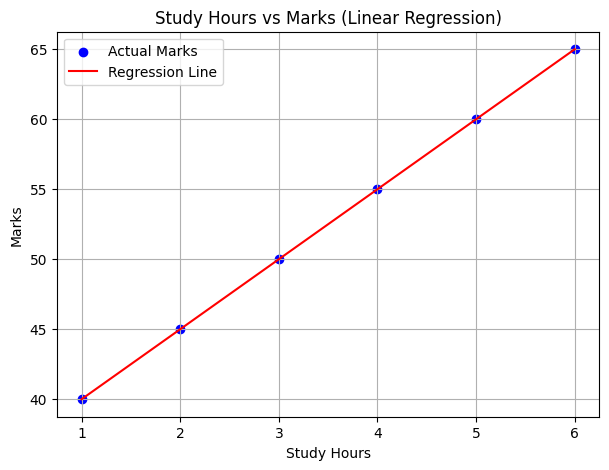

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(hours, y, color="blue", label="Actual Marks")
plt.plot(hours, y_pred, color="red", label="Regression Line")
plt.title("Study Hours vs Marks (Linear Regression)")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()
